## Optimizing progress variables for combustion using encoding-decoding networks

## 1) Setup

In [1]:
%run -i imports.py
%matplotlib inline
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/arialbd.ttf')
plt.rcParams['font.family'] = 'Arial'
import matplotlib.pyplot as plt

2026-08-13 09:23:00.593687: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-13 09:23:00.594045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-13 09:23:00.604971: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0


In [2]:
data_type = 'FPF'
# data_type = 'SLF'
# data_tag = 'NH3-H2-air-25perc'
data_tag = 'oxyfuel'
# target_variables_indices = [0,1,3,5,6,9]
target_variables_indices = [0,2,3,5,6,9,10]
pure_streams = True

# %run -i ../scripts/ammonia-Stagni-load-data.py
%run -i ../scripts/oxyfuel-load-data.py


Using: T, O2, OH, H2, H2O, CO, CO2 as target state variables at the decoder output.

25829 observations
27 state variables


## 2) Specify the cost function's hyper-parameters

In [3]:
power = 4
vertical_shift = 1
penalty_function = 'log-sigma-over-peak'

## 3) Parameterization with the optimized PV

In [ ]:
random_seeds_list = [0]
# random_seeds_list = [i for i in range(0,1)]


for random_seed in random_seeds_list:

    filename = '../scripts/f-PV-tps-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-1000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-VD-for-T-H-O2-OH-O-H2-H2O-CO-CO2-PV-source-rs-' + str(random_seed) + '.pkl'

    variance_data = pickle.load(open(filename, 'rb'))

    costs = analysis.cost_function_normalized_variance_derivative(
        variance_data,
        penalty_function=penalty_function,
        norm=None,
        power=power,
        vertical_shift=vertical_shift,
        integrate_to_peak=False
    )



0 [4.776516389351373, 50.83473027619429, 51.127858924915536, 4.30996843990755, 48.82338949170293, 8.803211518528606, 50.47525136725925, 49.31666112526807, 4.162436885617896, 2.531379635135001]


In [31]:
import pickle
costs_L2_RN = []

for random_seed in random_seeds_list:
    variance_data = pickle.load(open('../scripts/f-PV-tps-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-1000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-VD-for-T-H-O2-OH-O-H2-H2O-CO-CO2-PV-source-rs-' + str(random_seed) + '.pkl', 'rb'))
    costs = analysis.cost_function_normalized_variance_derivative(variance_data,
                                                                  penalty_function=penalty_function,
                                                                  norm=None,
                                                                  power=power,
                                                                  vertical_shift=vertical_shift,
                                                                  integrate_to_peak=False)
     
    costs_L2_RN.append(np.linalg.norm(costs)/len(costs))

In [36]:
print(costs_L2_RN)
idx_optimized_basis, = np.where(costs_L2_RN==np.min(costs_L2_RN))

[11.27140471307156]


In [7]:
model_weights_filename = '../scripts/f-PV-tps-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-best-model-weights-rs-' + str(idx_optimized_basis[0]) + '.h5'

In [8]:
hf = h5py.File(model_weights_filename, 'r')
optimized_basis = np.array(hf.get('0'))
hf.close()

In [9]:
PV_optimized = np.dot(state_space[:,1::], optimized_basis)
PV_optimized_source = np.dot(state_space_sources[:,1::], optimized_basis)
T = state_space[:,0]
PV_optimized = np.dot(state_space[:,1:], optimized_basis)

In [13]:
VarianceData_optimized = pickle.load(open('../scripts/f-PV-tps-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-1000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-VD-for-T-H-O2-OH-O-H2-H2O-CO-CO2-PV-source-rs-' + str(idx_optimized_basis[0]) + '.pkl', 'rb'))

In [14]:
sigmas_optimized = VarianceData_optimized.bandwidth_values
D_hat_optimized = analysis.normalized_variance_derivative(VarianceData_optimized)

In [15]:
costs_optimized = analysis.cost_function_normalized_variance_derivative(VarianceData_optimized,
                                                              penalty_function=penalty_function,
                                                              norm=None,
                                                              power=power,
                                                              vertical_shift=vertical_shift,
                                                              integrate_to_peak=False)

L2_norm_cost_optimized = np.linalg.norm(costs_optimized)/len(costs_optimized)
L2_norm_cost_optimized

11.27140471307156

## Visualize the $(f, \text{PV})$ manifolds

<Figure size 2500x1000 with 0 Axes>

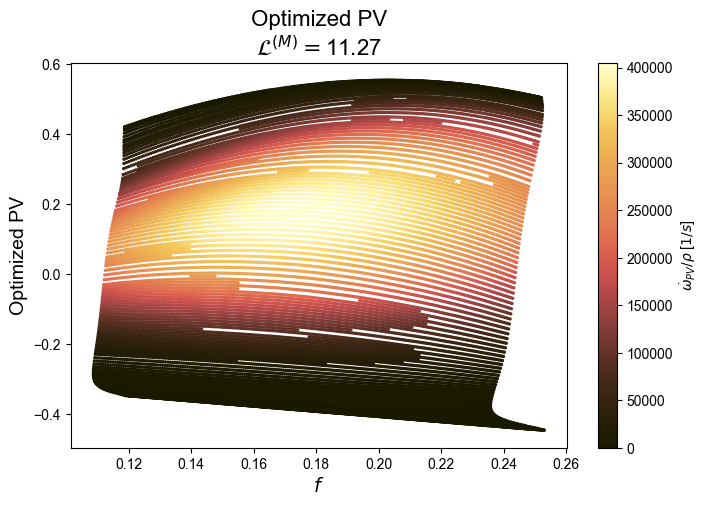

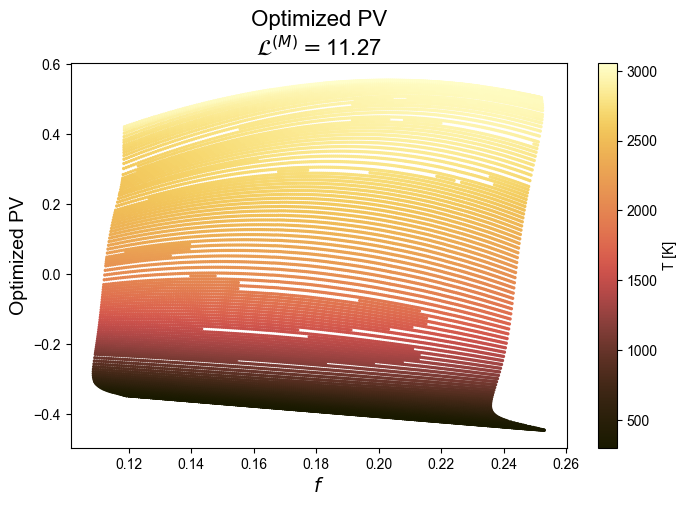

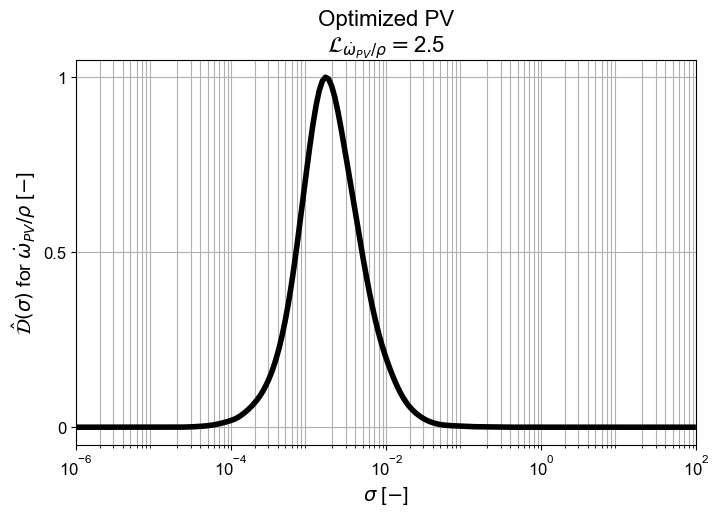

In [38]:
figure = plt.figure(figsize=(25, 10))
spec = figure.add_gridspec(ncols=7, nrows=3, width_ratios=[1,0,1,0,1,0,1], height_ratios=[1,0.2,0.9])

cmap = cmc.lajolla

fontsize = 20
fontsize_axes = 16
fontsize_subfigures = 26
s = 2

x_pos = -0.2
y_pos = 1.2

hfont = {'fontname':'Arial', 'fontweight':'bold'}

# # Manifolds - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
figure = plt.figure(figsize=(8,5))
figure_a = figure.add_subplot(111)
scat = plt.scatter(mf,PV_optimized,c=PV_optimized_source,s=2,cmap=cmc.lajolla,zorder=10)
plt.xlabel('$f$', fontsize=14)
plt.ylabel('Optimized PV', fontsize=14)
plt.title('Optimized PV\n'+ '$\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized,2)),fontsize=16)
cbar = plt.colorbar(scat)
cbar.set_label('$\dot{\omega}_{PV}/\\rho$ [$1/s$]', rotation=90)
plt.show()
#####
figure = plt.figure(figsize=(8,5))
figure_a = figure.add_subplot(111)
scat = plt.scatter(mf, PV_optimized,c=T,s=2,cmap=cmc.lajolla,zorder=10)
plt.xlabel('$f$', fontsize=14)
plt.ylabel('Optimized PV', fontsize=14)
plt.title('Optimized PV\n'+ '$\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized,2)),fontsize=16)
cbar = plt.colorbar(scat)
cbar.set_label('T [K]',rotation=90)
plt.show()

#####
figure = plt.figure(figsize=(8,5))
plt.semilogx(sigmas_optimized[1:-1],D_hat_optimized[0]['PV-source'],lw=4,c='k')
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2],fontsize=12)
plt.yticks([0,0.5,1],['0','0.5','1'],fontsize=12)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Optimized PV\n'+ '$\\mathcal{L}_{\\dot{\\omega}_{PV}/\\rho}=$'+ str(round(costs_optimized[-1],1)),fontsize=16)
plt.grid(True, which="both")
plt.show()


## 4) Visualize the individual costs, $\mathcal{L}_i$

In [39]:
# names_neat = ['$T$', '$Y_{H_2}$', '$Y_{H}$', '$Y_{O_2}$', '$Y_{O}$', '$Y_{H_2O}$', '$Y_{OH}$', '$Y_{H_2O_2}$', '$Y_{NO}$', '$Y_{N_2O}$', '$Y_{NO_2}$', '$Y_{NH_2}$', '$\\frac{\dot{\omega}_{PV}}{\\rho}$']
names_neat = ['$T$', '$Y_{H}$', '$Y_{O_2}$', '$Y_{OH}$', '$Y_{O}$', '$Y_{H2}$', '$Y_{H_2O}$', '$Y_{CO}$', '$Y_{CO_2}$', '$\\frac{\dot{\omega}_{PV}}{\\rho}$']

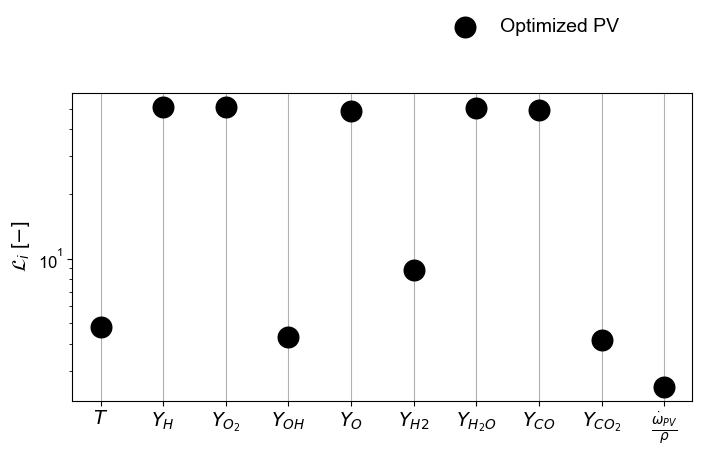

: 

In [ ]:
figure = plt.figure(figsize=(8, 4))
spec = figure.add_gridspec(ncols=1, nrows=1, width_ratios=[1], height_ratios=[1])

x_range = [i for i in range(0,len(names_neat))]
fontsize_axes = 12
fontsize = 14
s = 2

############################ Optimized PV ###########################
figure_a = figure.add_subplot(spec[0,0])
plt.scatter(x_range, costs_optimized, c='k', s=220, zorder=10, label='Optimized PV')
figure_a.xaxis.grid(True, alpha=1, zorder=1)
figure_a.tick_params(which='minor', labelsize=fontsize_axes)
figure_a.tick_params(which='major', labelsize=fontsize_axes)
plt.xticks(x_range, names_neat, fontsize=fontsize)
plt.ylabel('$\mathcal{L}_i$ [$-$]', fontsize=fontsize)
plt.yscale('log')
plt.legend(frameon=False, fontsize=fontsize, ncol=2, bbox_to_anchor=(0.91,1.3))

## 5) Comparison of the PV definitions

In [ ]:
########################## Comparison PV definitions ##########################
data_state_space = pd.read_csv("../data/freely-propagating-flame-oxyfuel-state-space.csv", header=None)
VD_target_variables_names = ['T','H','O2','OH','O','H2','H2O','CO','CO2', 'PV_ST']
position_VD_target_variables = [0,1,2,3,4,5,6,9,10]
VD_target_variables = data_state_space.iloc[:, position_VD_target_variables].to_numpy()
bandwidth_values = np.logspace(-6,2,200)
VarianceData_PM = pickle.load(open("../scripts/VarianceData_PM.pkl", "rb")) #Pierce & Moin PV definition
VarianceData_IP = pickle.load(open("../scripts/VarianceData_IP.pkl", "rb")) #Ihme & Pitsch PV definition
VarianceData_F = pickle.load(open("../scripts/VarianceData_F.pkl", "rb"))   #Fiorina et al. PV definition

Cost of Pierce & Moin: 0.3068249387098999
T 0.9070680732853276
H 0.8310549489820762
O2 0.8276053831623381
OH 0.8879712389544331
O 0.9530876692671946
H2 1.5058085087223645
H2O 0.8413011410807141
CO 0.870885766784048
CO2 0.9599320120947374
PV_ST 0.9293930413543183


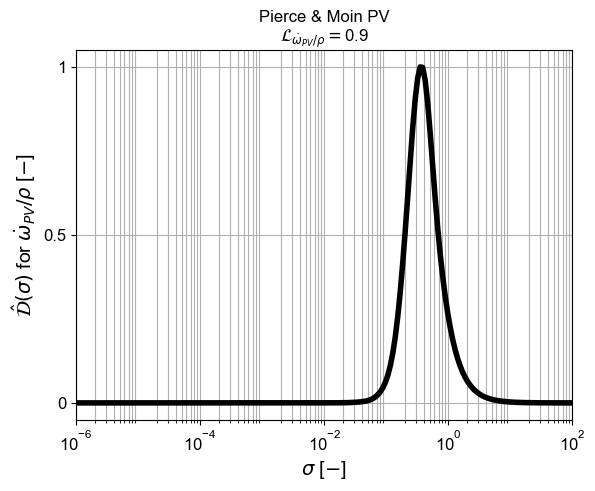

In [26]:
D_hat_PM = analysis.normalized_variance_derivative(VarianceData_PM)
sigmas_PM = VarianceData_PM.bandwidth_values

costs_PM = analysis.cost_function_normalized_variance_derivative(
    VarianceData_PM,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_PM = np.linalg.norm(costs_PM) / len(costs_PM)

print("Cost of Pierce & Moin:", L2_norm_cost_PM)
for name, cost in zip(VD_target_variables_names, costs_PM):
    print(name, cost)


plt.figure()
plt.semilogx(sigmas_PM[1:-1], D_hat_PM[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Pierce & Moin PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_PM[-1], 1)))
plt.savefig("D_hat_PM_PV_source.png", dpi=300, bbox_inches="tight")
plt.grid(True, which="both")
plt.show()

Cost of Ihme & Pitsch: 0.41161885545194554
T 0.9268548135265079
H 0.8394823878711539
O2 0.8443075003464471
OH 0.9750825317802954
O 1.0555308262521523
H2 2.888087918015837
H2O 0.8427511031911421
CO 0.8611550709273949
CO2 1.189989185962549
PV_ST 1.1800371622750885


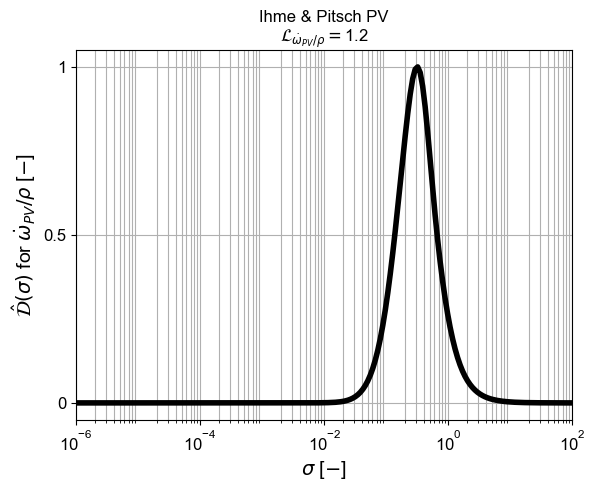

In [27]:
D_hat_IP = analysis.normalized_variance_derivative(VarianceData_IP)
sigmas_IP = VarianceData_IP.bandwidth_values


costs_IP = analysis.cost_function_normalized_variance_derivative(
    VarianceData_IP,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_IP = np.linalg.norm(costs_IP) / len(costs_IP)

print("Cost of Ihme & Pitsch:", L2_norm_cost_IP)
for name, cost in zip(VD_target_variables_names, costs_IP):
    print(name, cost)



plt.figure()
plt.semilogx(sigmas_IP[1:-1], D_hat_IP[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Ihme & Pitsch PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_IP[-1], 1)))
plt.savefig("D_hat_IP_PV_source.png", dpi=300, bbox_inches="tight")
plt.grid(True, which="both")
plt.show()

Cost of Fiorina et al: 0.3562140928636346
T 0.9708174270222147
H 0.8210308316372105
O2 0.8453537230034831
OH 0.9179141860264125
O 0.9903781330483261
H2 2.1966099263185024
H2O 0.8613470594253949
CO 0.8744653619208478
CO2 1.0444555966127778
PV_ST 1.0543436765854641


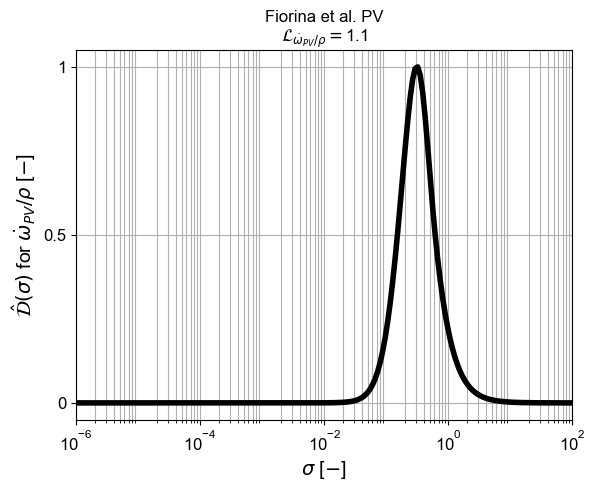

In [28]:
D_hat_F = analysis.normalized_variance_derivative(VarianceData_F)
sigmas_F = VarianceData_F.bandwidth_values


costs_F = analysis.cost_function_normalized_variance_derivative(
    VarianceData_F,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_F = np.linalg.norm(costs_F) / len(costs_F)

print("Cost of Fiorina et al:", L2_norm_cost_F)
for name, cost in zip(VD_target_variables_names, costs_F):
    print(name, cost)


plt.figure()
plt.semilogx(sigmas_F[1:-1], D_hat_F[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Fiorina et al. PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_F[-1], 1)))
plt.savefig("D_hat_F_PV_source.png", dpi=300, bbox_inches="tight")
plt.grid(True, which="both")
plt.show()

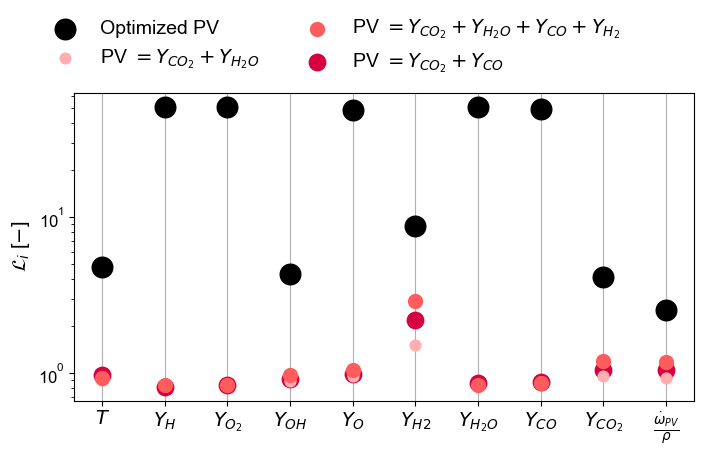

In [29]:
figure = plt.figure(figsize=(8, 4))
spec = figure.add_gridspec(ncols=1, nrows=1, width_ratios=[1], height_ratios=[1])

x_range = [i for i in range(0,len(names_neat))]
fontsize_axes = 12
fontsize = 14
s = 2

figure_a = figure.add_subplot(spec[0,0])
plt.scatter(x_range, costs_optimized, c='k', s=220, zorder=10, label='Optimized PV')
plt.scatter(x_range, costs_PM, c='#ffafaf', s=60, zorder=30, label='PV $= Y_{CO_2} + Y_{H_2O} $')
plt.scatter(x_range, costs_IP, c='#ff5d5d', s=100, zorder=40, label='PV $ = Y_{CO_2} + Y_{H_2O} + Y_{CO} + Y_{H_2}$')
plt.scatter(x_range, costs_F, c='#d70040', s=140, zorder=20, label='PV $ = Y_{CO_2} + Y_{CO}$')
figure_a.xaxis.grid(True, alpha=1, zorder=1)
figure_a.tick_params(which='minor', labelsize=fontsize_axes)
figure_a.tick_params(which='major', labelsize=fontsize_axes)
plt.xticks(x_range, names_neat, fontsize=fontsize)
plt.ylabel('$\mathcal{L}_i$ [$-$]', fontsize=fontsize)
plt.yscale('log')
plt.legend(frameon=False, fontsize=fontsize, ncol=2, bbox_to_anchor=(0.91,1.3))